# euclid_cutouts — Tutorial

This notebook shows how to use the `euclid_cutouts` library to produce colour
cutout images from Euclid data. Three workflows are demonstrated:

1. **Single cutout** — render one (4, H, W) IYJH array through azulero / bulk_euclid
2. **FITS-input mode** — batch-render a directory of pre-made FITS cutout files
3. **ML-inference loop** — load FITS cutouts on the fly, run a classifier, and
   keep only the high-confidence detections (FITS + colour images)

## Install

```bash
pip install -e /media/user/euclid_cutouts
```

In [1]:
import os
import numpy as np
from astropy.io import fits
from PIL import Image

from euclid_cutouts import (
    load_fits_cutout,
    render_azulero,
    render_stci,
    render_bulk_variant,
    render_cutout,
    render_fits_dir,
)

CUTANA_ROOT = "/media/user/astronomaly-euclid"
BULK_ROOT   = "/media/user/bulk-euclid-cutouts"

## 1. Render a single cutout

`render_cutout` takes a `(4, H, W)` IYJH float32 array (band order: VIS,
NIR-Y, NIR-J, NIR-H) and returns a dict of `{name: (H, W, 3) uint8 RGB}`
arrays — one per enabled renderer/variant.

Here we load a real grade-A strong-lens candidate from Q1
(EUCL J040700.68-495323.8, galaxy-galaxy scale, LensKiller+Ecker+Bergamini)
from the `demo_fits/` directory.

Loaded demo_fits/EUCL_J040700_lens.fits
  shape=(4, 101, 101)  dtype=float32



All 8 renderers/variants: ['azulero', 'stci', 'gz_arcsinh_vis_y', 'gz_arcsinh_vis_only', 'gz_arcsinh_triple', 'sw_mtf_vis_only', 'sw_mtf_vis_y', 'sw_mtf_vis_y_j']


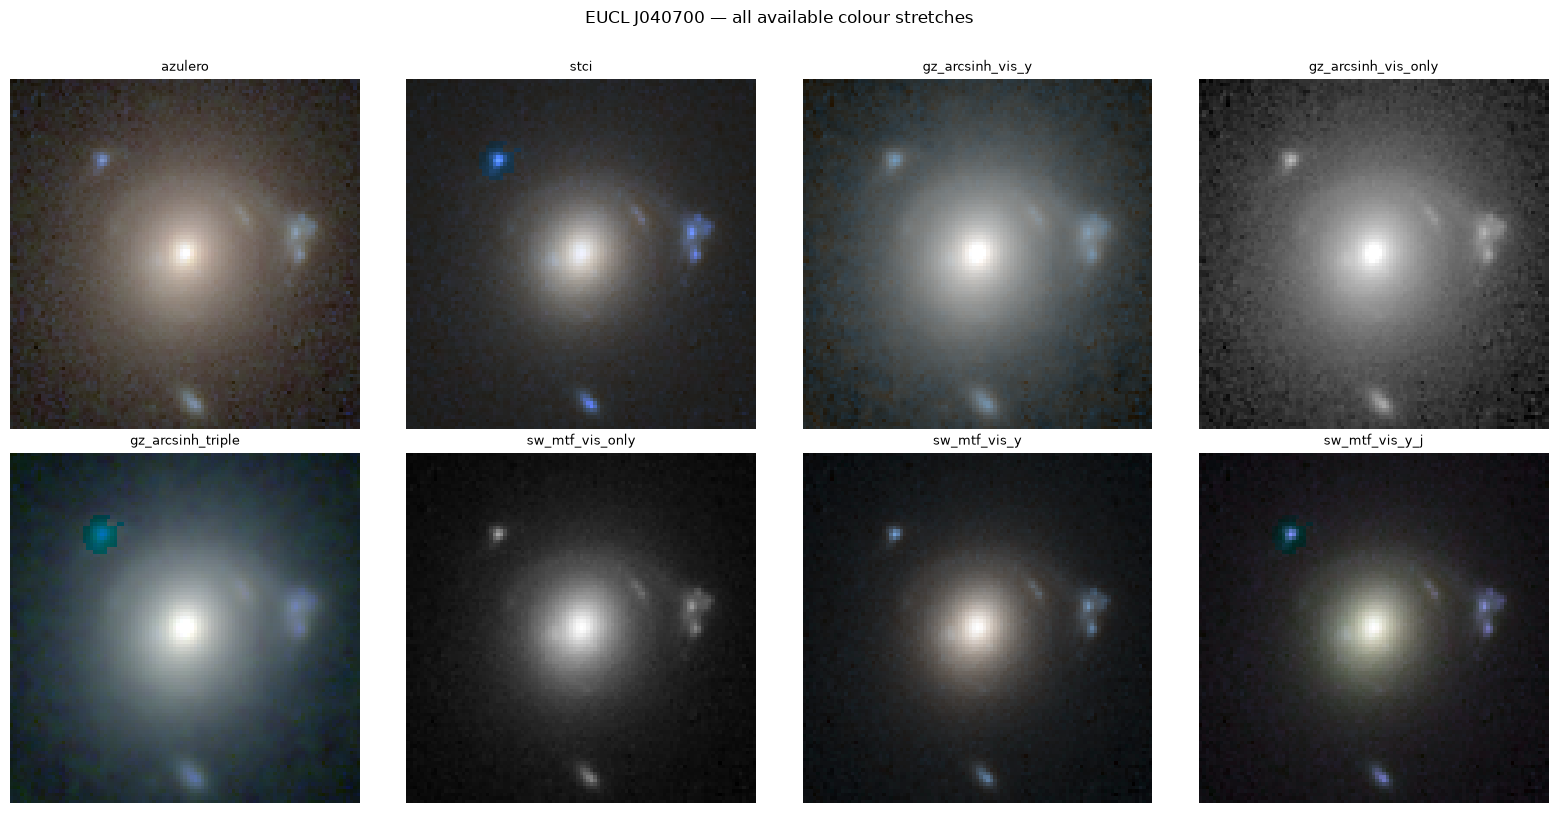

In [2]:
# Load a real Q1 lens cutout (4-band FITS extracted from tile 102019593)
DEMO_DIR = os.path.join(os.path.dirname(os.getcwd()), "demo_fits")
if not os.path.isdir(DEMO_DIR):
    DEMO_DIR = "demo_fits"

lens_path = os.path.join(DEMO_DIR, "EUCL_J040700_lens.fits")
iyjh = load_fits_cutout(lens_path, band_order=["VIS", "NIR_Y", "NIR_J", "NIR_H"])
print(f"Loaded {lens_path}")
print(f"  shape={iyjh.shape}  dtype={iyjh.dtype}")

# Render through ALL available colour stretches
ALL_BULK_VARIANTS = [
    "gz_arcsinh_vis_y",     # VIS+Y composite (arcsinh)
    "gz_arcsinh_vis_only",  # VIS-only (arcsinh)
    "gz_arcsinh_triple",    # VIS+Y+J three-band (arcsinh)
    "sw_mtf_vis_only",      # VIS-only (midtone transfer)
    "sw_mtf_vis_y",         # VIS+Y (midtone transfer + LAB luminosity)
    "sw_mtf_vis_y_j",       # VIS+Y+J (midtone transfer + LAB luminosity)
]

results = render_cutout(
    iyjh,
    renderers=["azulero", "stci", "bulk_euclid"],
    bulk_variants=ALL_BULK_VARIANTS,
    cutana_root=CUTANA_ROOT,
    bulk_euclid_root=BULK_ROOT,
)

print(f"\nAll {len(results)} renderers/variants:", list(results.keys()))

import matplotlib.pyplot as plt
n = len(results)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(4 * ((n + 1) // 2), 8))
axes = axes.flatten()
for ax, (name, rgb) in zip(axes, results.items()):
    ax.imshow(rgb, origin="upper")
    ax.set_title(name, fontsize=9)
    ax.axis("off")
for ax in axes[n:]:
    ax.axis("off")
plt.suptitle("EUCL J040700 — all available colour stretches", y=1.01)
plt.tight_layout()
plt.show()

### Using a single renderer

You don't have to run all colour stretches — just pass the one you want.
`render_azulero` and `render_bulk_variant` work on individual cutouts:

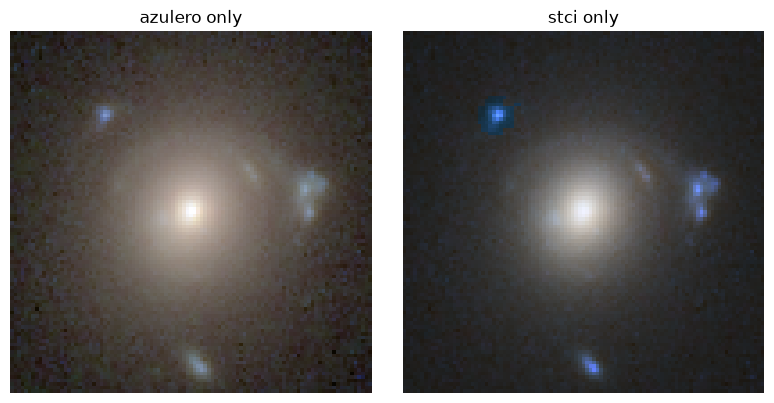

Keys: ['stci']


In [3]:
# Azulero only
rgb_azulero = render_azulero(iyjh, cutana_root=CUTANA_ROOT)

# STCI only
rgb_stci = render_stci(iyjh)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(rgb_azulero); axes[0].set_title("azulero only"); axes[0].axis("off")
axes[1].imshow(rgb_stci);    axes[1].set_title("stci only"); axes[1].axis("off")
plt.tight_layout()
plt.show()

# render_cutout also accepts a single renderer:
out = render_cutout(iyjh, renderers=["stci"])
print("Keys:", list(out.keys()))  # only stci

## 2. Batch-render a directory of FITS cutouts

`render_fits_dir` batch-processes a folder of FITS cutout files. Here we use
`demo_fits/` which contains 3 real grade-A Q1 lens candidates:

- EUCL J040700.68-495323.8 (galaxy-galaxy, LensKiller+Ecker+Bergamini)
- EUCL J033036.29-294946.3 (Bergamini+25)
- EUCL J040408.75-460534.5 (Ecker+25)

In [4]:
# demo_fits/ already contains 3 real Q1 lens cutouts (4-band IYJH)
print("Input FITS files:")
for fn in sorted(os.listdir(DEMO_DIR)):
    if fn.endswith(".fits"):
        print(f"  {fn}")

Input FITS files:
  EUCL_J033036_lens.fits
  EUCL_J040408_lens.fits
  EUCL_J040700_lens.fits


In [5]:
import shutil

demo_out_dir = "demo_output"
shutil.rmtree(demo_out_dir, ignore_errors=True)

totals = render_fits_dir(
    input_dir=DEMO_DIR,
    output_dir=demo_out_dir,
    enable_azulero=True,
    enable_stci=True,
    enable_bulk_euclid=True,
    bulk_variants=["gz_arcsinh_vis_y"],
    band_order=["VIS", "NIR_Y", "NIR_J", "NIR_H"],
    fmt="jpg",
    jpeg_quality=95,
    n_workers=1,
    progress_bar=True,
    cutana_root=CUTANA_ROOT,
    bulk_euclid_root=BULK_ROOT,
)

print("\nTotals:", totals)
print("\nOutput tree:")
for root, dirs, files in os.walk(demo_out_dir):
    level = root.replace(demo_out_dir, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files):
        print(f"{indent}  {f}")

Rendering FITS cutouts:   0%|          | 0/3 [00:00<?, ?file/s]

Rendering FITS cutouts:   0%|          | 0/3 [00:00<?, ?file/s, azulero=1  gz_arcsinh_vis_y=1  stci=1]

Rendering FITS cutouts:   0%|          | 0/3 [00:00<?, ?file/s, azulero=2  gz_arcsinh_vis_y=2  stci=2]

Rendering FITS cutouts:   0%|          | 0/3 [00:00<?, ?file/s, azulero=3  gz_arcsinh_vis_y=3  stci=3]

Rendering FITS cutouts: 100%|██████████| 3/3 [00:00<00:00, 43.79file/s, azulero=3  gz_arcsinh_vis_y=3  stci=3]


Totals: {'azulero': 3, 'stci': 3, 'gz_arcsinh_vis_y': 3}

Output tree:
demo_output/
  azulero/
    EUCL_J033036_lens.jpg
    EUCL_J040408_lens.jpg
    EUCL_J040700_lens.jpg
  stci/
    EUCL_J033036_lens.jpg
    EUCL_J040408_lens.jpg
    EUCL_J040700_lens.jpg
  gz_arcsinh_vis_y/
    EUCL_J033036_lens.jpg
    EUCL_J040408_lens.jpg
    EUCL_J040700_lens.jpg


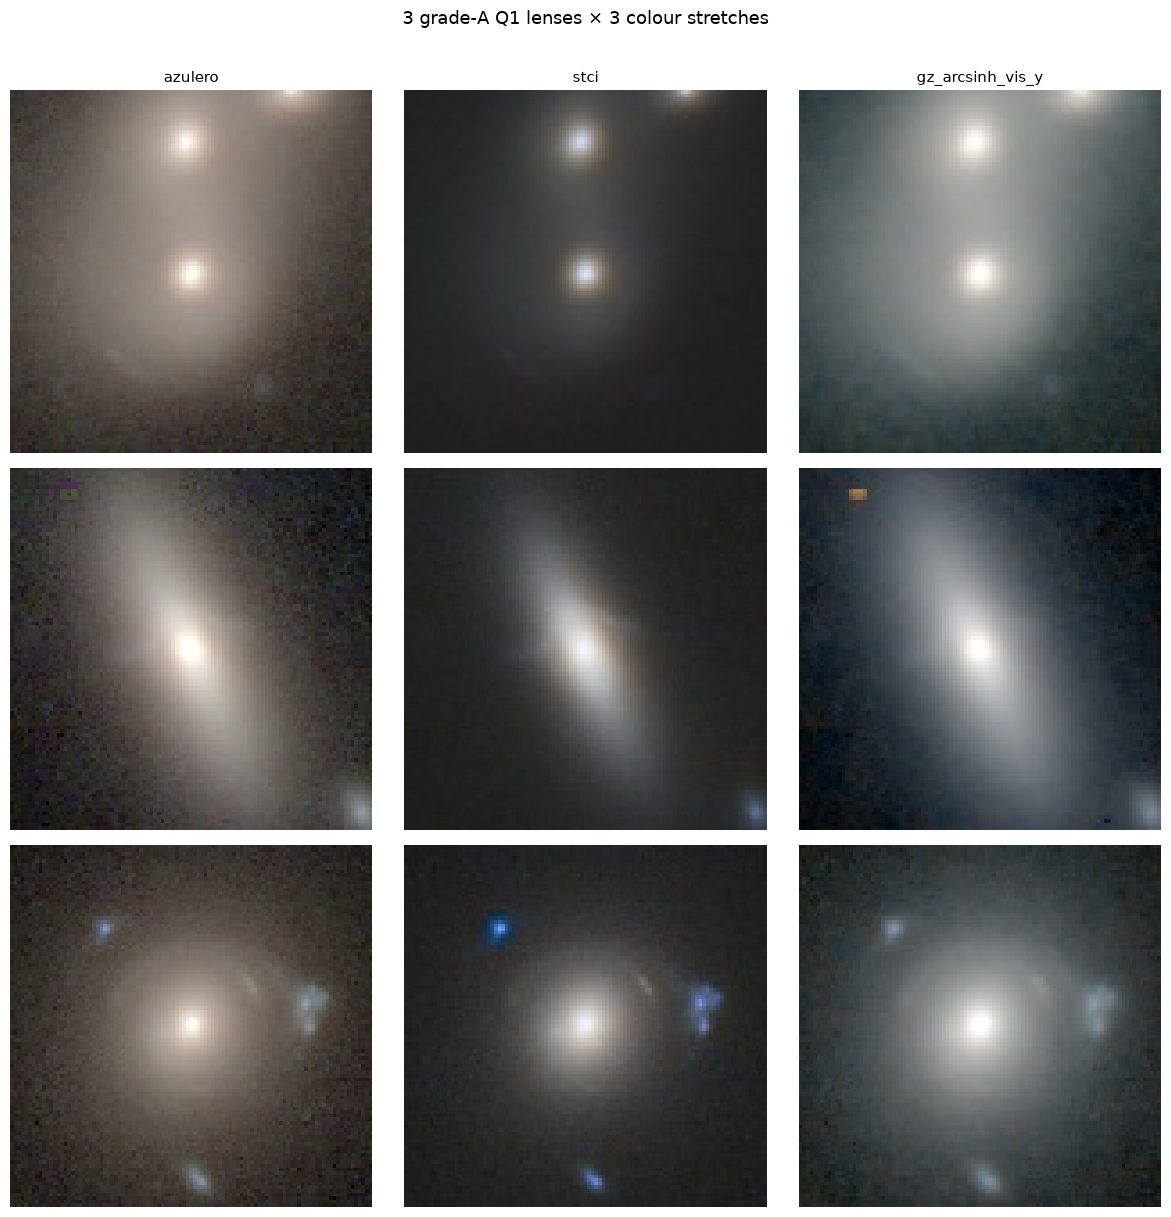

In [6]:
# Display all 3 lenses x 3 renderers
variants = ["azulero", "stci", "gz_arcsinh_vis_y"]
stems = sorted(os.path.splitext(f)[0] for f in os.listdir(DEMO_DIR) if f.endswith(".fits"))

fig, axes = plt.subplots(len(stems), len(variants),
                         figsize=(4 * len(variants), 4 * len(stems)))
for row, stem in enumerate(stems):
    for col, var in enumerate(variants):
        img_path = os.path.join(demo_out_dir, var, f"{stem}.jpg")
        axes[row, col].imshow(Image.open(img_path))
        if row == 0:
            axes[row, col].set_title(var, fontsize=11)
        if col == 0:
            axes[row, col].set_ylabel(stem.replace("_lens", ""), fontsize=9)
        axes[row, col].axis("off")
plt.suptitle("3 grade-A Q1 lenses × 3 colour stretches", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### About `band_order`

Multi-extension FITS cutout files store each band as a separate HDU
(CHANNEL_1, CHANNEL_2, ...), but different tools write the bands in different
orders. `band_order` tells the loader which band each extension corresponds to:

```
CHANNEL_1 → band_order[0]
CHANNEL_2 → band_order[1]
...
```

The loader maps each band to its slot in the internal (4, H, W) IYJH array:
VIS → index 0, NIR_Y → 1, NIR_J → 2, NIR_H → 3. Bands not present in the
FITS file are zero-filled.

| Source of FITS cutouts | `band_order` to use |
|---|---|
| This pipeline's `demo_fits/` | `["VIS", "NIR_Y", "NIR_J", "NIR_H"]` (default) |
| Cutana 3-band (workspace convention) | `["NIR_Y", "NIR_J", "VIS"]` |
| Single-band VIS-only | `["VIS"]` |

```python
# Cutana 3-band example
totals = render_fits_dir(
    input_dir="/path/to/cutana_output",
    output_dir="cutouts",
    band_order=["NIR_Y", "NIR_J", "VIS"],
    enable_azulero=True,
    cutana_root=CUTANA_ROOT,
)
```

## 3. CSV-mode (tile-based pipeline via CLI)

The original tile-based pipeline reads a CSV of sources, resolves tiles via
HEALPix, loads full tile FITS, extracts cutouts, and renders through all four
colour stretches (azulero, eummy, bulk_euclid). This mode also supports eummy,
which needs tile-level FITS on disk.

Run from the terminal:

```bash
# Edit the CONFIG block at the top of the script first, then:
python scripts/make_colour_cutouts.py
```

Or switch to FITS-input mode from the same script by setting
`INPUT_FITS_DIR` in the CONFIG block — the script then calls `render_fits_dir`
internally.

## 4. ML-inference loop with Zoobot Euclid

Here we use [Zoobot Euclid](https://huggingface.co/mwalmsley/zoobot-encoder-euclid)
(Walmsley+25), a ConvNeXt encoder pretrained on Euclid morphology data. It
produces a 640-dim feature vector for each cutout.

The workflow:
1. Load each FITS cutout → render to RGB → resize to 224×224
2. Run Zoobot encoder → get 640-dim feature embedding
3. Use the feature-norm as a proxy "interestingness" score (in real use you'd
   train a classification head or use a downstream classifier)
4. Only keep cutouts above a threshold — save the FITS + colour images

**Requires:** `feat` conda environment with `torch`, `timm`, `zoobot`.

In [7]:
def ml_filter_and_render(
    fits_dir, output_dir, predict_fn, *,
    threshold=0.5, band_order=None, renderers=None, bulk_variants=None,
    fmt="jpg", jpeg_quality=95, save_fits=True,
    cutana_root=None, bulk_euclid_root=None,
):
    """Load FITS cutouts, run predict_fn(iyjh)->score, keep above threshold."""
    import glob as _g
    if renderers is None:
        renderers = ["azulero", "stci"]
    if bulk_variants is None:
        bulk_variants = ["gz_arcsinh_vis_y"]
    if band_order is None:
        band_order = ["VIS", "NIR_Y", "NIR_J", "NIR_H"]

    fits_files = sorted(_g.glob(os.path.join(fits_dir, "*.fits")))
    print(f"Scanning {len(fits_files)} FITS files, threshold={threshold:.4f}")

    fits_out = os.path.join(output_dir, "fits")
    if save_fits:
        os.makedirs(fits_out, exist_ok=True)
    colour_dirs = {}
    if "azulero" in renderers:
        d = os.path.join(output_dir, "azulero")
        os.makedirs(d, exist_ok=True)
        colour_dirs["azulero"] = d
    if "stci" in renderers:
        d = os.path.join(output_dir, "stci")
        os.makedirs(d, exist_ok=True)
        colour_dirs["stci"] = d
    if "bulk_euclid" in renderers:
        for v in bulk_variants:
            d = os.path.join(output_dir, v)
            os.makedirs(d, exist_ok=True)
            colour_dirs[v] = d

    save_kw = {"quality": jpeg_quality} if fmt == "jpg" else {}
    results, n_kept = [], 0

    for fp in fits_files:
        stem = os.path.splitext(os.path.basename(fp))[0]
        iyjh_local = load_fits_cutout(fp, band_order=band_order)
        if iyjh_local is None:
            results.append({"stem": stem, "fits_path": fp, "probability": 0.0, "kept": False})
            continue
        prob = float(predict_fn(iyjh_local))
        kept = prob >= threshold
        results.append({"stem": stem, "fits_path": fp, "probability": prob, "kept": kept})
        if not kept:
            continue
        if save_fits:
            shutil.copy2(fp, os.path.join(fits_out, f"{stem}.fits"))
        colour_results = render_cutout(
            iyjh_local, renderers=renderers, bulk_variants=bulk_variants,
            cutana_root=cutana_root, bulk_euclid_root=bulk_euclid_root)
        for name, rgb in colour_results.items():
            Image.fromarray(rgb).save(os.path.join(colour_dirs[name], f"{stem}.{fmt}"), **save_kw)
        n_kept += 1

    print(f"Done: {n_kept}/{len(fits_files)} kept (threshold={threshold:.4f})")
    return results

In [8]:
import torch
import timm

# Load Zoobot Euclid encoder from HuggingFace
zoobot_model = timm.create_model(
    "hf_hub:mwalmsley/zoobot-encoder-euclid",
    pretrained=True,
    num_classes=0,  # encoder only — no classification head
)
zoobot_model.eval()
print(f"Zoobot encoder loaded: {type(zoobot_model).__name__}, "
      f"output features: {zoobot_model.num_features}")

Zoobot encoder loaded: ConvNeXt, output features: 640


In [9]:
def zoobot_predict(iyjh):
    """Render cutout to RGB, resize to 224x224, run Zoobot, return feature norm."""
    # Render to RGB via gz_arcsinh (fast, no azulero dependency)
    rgb = render_bulk_variant("gz_arcsinh_vis_y",
                              iyjh[0], iyjh[1], iyjh[2],
                              bulk_euclid_root=BULK_ROOT)
    if rgb is None:
        return 0.0

    # Resize to 224x224 and normalise to [0, 1] float tensor
    img = Image.fromarray(rgb).resize((224, 224), Image.LANCZOS)
    x = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
    x = x.unsqueeze(0)  # (1, 3, 224, 224)

    with torch.no_grad():
        features = zoobot_model(x)  # (1, 640)

    # Feature-norm as proxy score (higher = more "interesting" morphology).
    # In production, replace this with a trained classification head.
    norm = features.norm().item()
    return norm

# Test on one lens
test_iyjh = load_fits_cutout(
    os.path.join(DEMO_DIR, "EUCL_J040700_lens.fits"),
    band_order=["VIS", "NIR_Y", "NIR_J", "NIR_H"],
)
score = zoobot_predict(test_iyjh)
print(f"Test score for EUCL_J040700: {score:.4f}")

Test score for EUCL_J040700: 21.6095


In [10]:
# Run Zoobot on all 3 lenses and extract features + scores
import glob as _glob

fits_files = sorted(_glob.glob(os.path.join(DEMO_DIR, "*.fits")))
all_features = {}
all_scores = {}

for fp in fits_files:
    stem = os.path.splitext(os.path.basename(fp))[0]
    iyjh_i = load_fits_cutout(fp, band_order=["VIS", "NIR_Y", "NIR_J", "NIR_H"])

    # Get features
    rgb = render_bulk_variant("gz_arcsinh_vis_y",
                              iyjh_i[0], iyjh_i[1], iyjh_i[2],
                              bulk_euclid_root=BULK_ROOT)
    img = Image.fromarray(rgb).resize((224, 224), Image.LANCZOS)
    x = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0

    with torch.no_grad():
        feats = zoobot_model(x.unsqueeze(0)).squeeze()

    all_features[stem] = feats.numpy()
    all_scores[stem] = feats.norm().item()
    print(f"  {stem}: feature norm = {all_scores[stem]:.4f}, "
          f"feature shape = {feats.shape}")

print(f"\nScores: { {k: f'{v:.4f}' for k, v in all_scores.items()} }")

  EUCL_J033036_lens: feature norm = 16.8225, feature shape = torch.Size([640])


  EUCL_J040408_lens: feature norm = 17.9998, feature shape = torch.Size([640])


  EUCL_J040700_lens: feature norm = 21.6095, feature shape = torch.Size([640])

Scores: {'EUCL_J033036_lens': '16.8225', 'EUCL_J040408_lens': '17.9998', 'EUCL_J040700_lens': '21.6095'}


In [11]:
# Use the scores to filter: keep only above median score
scores_arr = np.array(list(all_scores.values()))
threshold = float(np.median(scores_arr))
print(f"Threshold (median feature norm): {threshold:.4f}\n")

ml_out_dir = "demo_ml_output"
shutil.rmtree(ml_out_dir, ignore_errors=True)

results = ml_filter_and_render(
    fits_dir=DEMO_DIR,
    output_dir=ml_out_dir,
    predict_fn=zoobot_predict,
    threshold=threshold,
    renderers=["azulero", "stci"],
    cutana_root=CUTANA_ROOT,
)

Threshold (median feature norm): 17.9998

Scanning 3 FITS files, threshold=17.9998


Done: 2/3 kept (threshold=17.9998)


In [12]:
# --- Inspect results ---
import pandas as pd

df_results = pd.DataFrame(results)
df_results["probability"] = df_results["probability"].round(4)
print(df_results[["stem", "probability", "kept"]].to_string(index=False))

print(f"\nKept cutouts saved to: {ml_out_dir}")
for sub in ["fits", "azulero", "stci"]:
    d = os.path.join(ml_out_dir, sub)
    if os.path.isdir(d):
        print(f"  {sub}/: {os.listdir(d)}")

             stem  probability  kept
EUCL_J033036_lens      16.8225 False
EUCL_J040408_lens      17.9998  True
EUCL_J040700_lens      21.6095  True

Kept cutouts saved to: demo_ml_output
  fits/: ['EUCL_J040408_lens.fits', 'EUCL_J040700_lens.fits']
  azulero/: ['EUCL_J040408_lens.jpg', 'EUCL_J040700_lens.jpg']
  stci/: ['EUCL_J040408_lens.jpg', 'EUCL_J040700_lens.jpg']


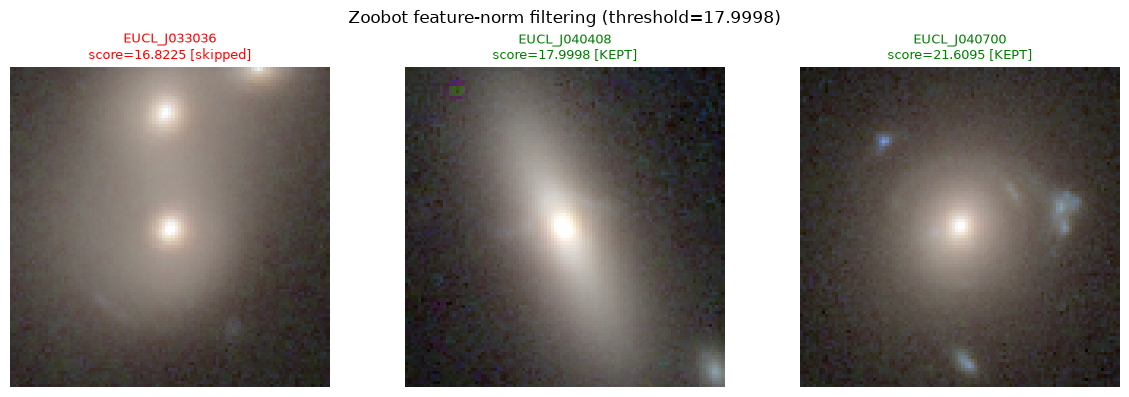

In [13]:
# --- Display kept vs rejected ---
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4),
                         squeeze=False)
for ax, r in zip(axes[0], results):
    # Load the rendered image (use azulero from batch output or render on the fly)
    iyjh_i = load_fits_cutout(r["fits_path"], band_order=["VIS", "NIR_Y", "NIR_J", "NIR_H"])
    rgb = render_azulero(iyjh_i, cutana_root=CUTANA_ROOT)
    ax.imshow(rgb)
    status = "KEPT" if r["kept"] else "skipped"
    ax.set_title(f"{r['stem'].replace('_lens','')}\nscore={r['probability']:.4f} [{status}]",
                 fontsize=9, color="green" if r["kept"] else "red")
    ax.axis("off")
plt.suptitle(f"Zoobot feature-norm filtering (threshold={threshold:.4f})")
plt.tight_layout()
plt.show()

## API summary

| Function | Input | Output | Use case |
|---|---|---|---|
| `load_fits_cutout(path, band_order)` | FITS file path | `(4, H, W)` float32 or None | Load any multi-extension FITS cutout |
| `render_azulero(iyjh)` | `(4, H, W)` float32 | `(H, W, 3)` uint8 RGB | Single azulero colour image |
| `render_stci(iyjh)` | `(4, H, W)` float32 | `(H, W, 3)` uint8 RGB | Single STCI colour image |
| `render_bulk_variant(variant, vis, y, j)` | per-band 2D arrays | `(H, W, 3)` uint8 RGB | Single bulk_euclid variant |
| `render_cutout(iyjh, renderers, ...)` | `(4, H, W)` float32 | `{name: RGB}` dict | Multi-renderer in one call |
| `render_fits_dir(input_dir, output_dir, ...)` | directory of FITS | `{name: count}` dict | Batch rendering with multiprocessing |

In [14]:
# --- Cleanup demo output ---
shutil.rmtree(demo_out_dir, ignore_errors=True)
shutil.rmtree(ml_out_dir, ignore_errors=True)
print("Cleaned up output dirs. demo_fits/ kept for re-runs.")

Cleaned up output dirs. demo_fits/ kept for re-runs.
